# Script for processing own data: 

First we import the necessary libraries:

In [19]:
import os
import pandas as pd
import neurokit2 as nk
import matplotlib.pyplot as plt
import json
import numpy as np

The imported libraries are: 
* OS
    * This library provides an interface for interactions with the operating system 
    * We use this for file handling, e.g. finding files, using os.listdir(), creating new folders, using os.makedirs(), and combinding new path names, using os.path.join() 
    * https://docs.python.org/3/library/os.html 
* Pandas (as pd) 
    * A library used for data analysis, using DataFrames
    * In this projects we particularly use pd.read_csb(), to import data from a given file into a DataFrame. Note, this is done for both .txt and .csv files 
    * This serves as a tool for data management 
    * https://pandas.pydata.org/docs/ 
* NeuroKit2 (as nk)
    * NeuroKit2 is a library specially developed for easy access to processing of biosignals
    * In this project we utilise several functions from this library, e.g. nk.ecg_clean, which is used to filter off noise allowing for more accurate calculations later on 
    * https://neuropsychology.github.io/NeuroKit/introduction.html 
* matplotlib.pyplot (as plt) 
    * Matplotlib is used to generate plots and graphs, which we will use at the very end, to visualise a number of functions, like how the noise filter changes the ECG signal
    * https://matplotlib.org/stable/ 
* json 
    * This library is used for storage and transfer of data 
    * In this project we only briefly employ it to extract metadata from the file header, to use in later calculations 
    * (https://www.json.org/json-en.html)
    * https://docs.python.org/3/library/json.html
* numpy (as np)
    * NumPy is a library generally used for numerical calculation 
    * In this project it is used to generate a time vector for the ECG signal 
    * https://numpy.org/doc/

## Part 1 : extract files and sort them into folders 

### Define input and output directories 
Now we determine the input and output directories. 

The input folder contains the raw files, while the output directory is the location where folders will be created to store the processed files. 

In [20]:
input_folder: str = r"C:\Users\Laerke\Documents\DTU\Teknisk Biomedicin\SS 26\BSc\EKG\EKG filer - 04.02.26"
output_base  = r"C:\Users\Laerke\Documents\DTU\Teknisk Biomedicin\SS 26\BSc\EKG\Processed CSV"

### Create folders for each condition 
Based on the experimental conditions, we now create folders for each file category
* baseline : the baseline test, data recorded before any induced motion sickness 
* VR : data recorded during VR exposure (visual stimulus) 
* post : data recorded after VR exposure has ended 

In this os.makedirs() is employed to create folders for each defined category.
Meanwhile exist_ok=True prevents an error, if a given folder already exists (ie if we run the script a second time)

In [21]:
# define categories 
# -> based on experimental conditions 
categories = ["baseline" , "VR" , "post"]
for cat in categories :
    
    # create one folder for each category, inside the output directory 
    # exist_ok=True to prevent erros if the folder already exists 
    os.makedirs(os.path.join(output_base , cat) , exist_ok = True)


### File extraction and prepocessing 

In this step, all the raw .txt files are sorted through to be categorised and converted into .csv files, containing the ECG data. 

#### Identifying .txt files 
First all the .txt files in the input folder are identified. 

This is done by looping through the input folder looking for all files with the ".txt" ending. 

These files are then stored in a list. 

This list can then be iterated through, in each of the following steps. 

In [22]:
# find .txt files in the input folder 
txt_files = [f for f in os.listdir(input_folder) if f.endswith(".txt")]

#### Categorising the files

In this part the stored .txt files are processed and sorted into their corresponding folders. 

To ensure each file is correctly categorised file.lower() is used to read the entire filename in lowercase. 

As multiple people have named the files there may be discrepancies in the naming convention for the files. 

Converting the filenames entirely into lowercase prevents a file from being missed due to a case mismatch. 

Then an if-statement is used to sort the files into the correct folder, based on the filename. 
* Files containing "baseline" are sorted into the folder named baseline 
* Files containging "vr" or "stim" are sorted into the folder named VR 
* Files containing "post" or "pr" in the name are sorted into the folder named post 

If none of the defined categories are detected in the filename, the file is skipped, and a message is printed informing of which file has not been sorted. 

#### Preparing the files for processing 
In this part, each file is read and relevant data is extracted. 

The raw .txt files contain both the signal data and metadata. 

For the first passover, the metadata is completely ignored, and the signal data is extracted separately. 

This is done using Pandas. 

Lines starting with #, which are the lines containing the metadata, are skipped when reading. 

The relevant data is listed in columns: 
* First column tells which number signal 
* The second column contains empty data points 
* The third column contains the meassurements, converted into millivolts 

Using sep = "\t" the contents are kept as those columns (tab separated)

To account for variations in the header, the columns are manually named, and only the ECG column is kept for later. 

#### Extracting metadata (sampling rate)  
To account for the possibility of changes in the sampling rate, we extract the sampling rate from the file header using json. 

There were several considerations in regards to preserving the sampling rate.
* Preserve the header when writing file contents over to a .csv file 
* Preserve the data in a metadata file using json 
* Establish a time vector 

Ultimately it was decided that preserving the header in the .csv files would be too cluttered.

Instead, a time vector was established, as this seemed like the most familiar solution. 

Additionally, in calculating the time vector, we also pull the sampling rate from the metadata, making both easily accessible for later calculations. 

#### Data processing 
Here the ECG is prepared for future analysis and calculations. 

First pd.to_numeric() is used to convert the values to a numeric format. 

This is done as they are initially read as strings. 

Here we also use errors="coerce" to handle any values that cannot be converted into numbers. 

These invalid values are instead replaced with NaN, preventing future errors when processing. 

Then a time vector is established, using the sampling rate. 


#### Save processed files 
Finally the processed file is saved as a .csv file in the corresponding category folder. 

#### Error handling 
For error handling we use a single try/except block. 

This allows for any problematic files to be skipped, without stopping the entire script, and then printing an error message with the file(s) in question. 

In [23]:
# Categorising the files
# loop through each of the files, determine category from the filename 
for file in txt_files :
    # combine filename with input folder to get path for the file 
    file_path = os.path.join(input_folder , file)
    
    # read everything in lowercase to prevent errors 
    fname_lower = file.lower()
    
    # sort into folder based on filename 
    if "baseline" in fname_lower :
        category = "baseline"
    elif "vr" in fname_lower or "stim" in fname_lower : 
        category = "VR"
    elif "post" in fname_lower or "pr" in fname_lower :
        category = "post" 
    else :
        # if none of the defines categories exist in filename, skip the file 
        print(f"Skipping {file} : no category detected.")
        continue

    # Preparing the files for processing 
    # try/except for error handling 
    try :
        # read file, ignore lines starting with # (metadata lines)
        df = pd.read_csv(
            file_path ,
            sep = "\t" ,        # split into horizontal strings 
            comment = "#" ,     # skip lines starting with # (metadata)
            header = None ,     # we remove old header entirely 
            names = ["trash1", "trash2", "ECG", "trash3"],   # manually rename columns 
            engine = "python"  
        )

        with open(file_path, "r") as infile :
            # use json to store necessary metadata from the header 
            # -> we need the sampling rate for future calculations 
            info = json.loads(infile.readlines()[1].replace("# ", "").replace("\n", ""))
    
        # Extracting metadata 
        # keep the ECG column
        df = df[["ECG"]] 

        # save the sampling rate 
        # find this in the data saved from the header 
        sampling_rate = info[list(info.keys())[0]]["sampling rate"]

        # Data processing 
        # convert to numeric (from string)
        # coerce to deal if something cannot be converted (replace w NaN)
        df["ECG"] = pd.to_numeric(df["ECG"] , errors = "coerce") 

        # a time vector is established (in secs)
        # sampling rate is used to calculate time vector 
        df["Time"] = np.arange(0, len(df["ECG"])) / sampling_rate  
        

        # Save processed files 
        # Output path
        output_csv = os.path.join(
            output_base ,
            category ,
            # change .txt files into .csv files 
            file.replace(".txt" , ".csv")
        )

        # save CSV, without index column 
        df.to_csv(output_csv , index = False) 

        print(f"Saved {output_csv}")

    except Exception as e :
        print(f"Error processing {file} : {e}")

Skipping Asher_testsignal.txt : no category detected.
Skipping Asher_testsignal_converted.txt : no category detected.
Saved C:\Users\Laerke\Documents\DTU\Teknisk Biomedicin\SS 26\BSc\EKG\Processed CSV\baseline\Baseline_Kanujah.csv
Saved C:\Users\Laerke\Documents\DTU\Teknisk Biomedicin\SS 26\BSc\EKG\Processed CSV\baseline\Baseline_Laerke.csv
Saved C:\Users\Laerke\Documents\DTU\Teknisk Biomedicin\SS 26\BSc\EKG\Processed CSV\baseline\Kanujah_Baseline1_converted.csv
Saved C:\Users\Laerke\Documents\DTU\Teknisk Biomedicin\SS 26\BSc\EKG\Processed CSV\baseline\Kanujah_baseline2.csv
Saved C:\Users\Laerke\Documents\DTU\Teknisk Biomedicin\SS 26\BSc\EKG\Processed CSV\baseline\Kanujah_Baseline2_converted.csv
Saved C:\Users\Laerke\Documents\DTU\Teknisk Biomedicin\SS 26\BSc\EKG\Processed CSV\post\Kanujah_Post.csv
Saved C:\Users\Laerke\Documents\DTU\Teknisk Biomedicin\SS 26\BSc\EKG\Processed CSV\post\Kanujah_Post1_converted.csv
Saved C:\Users\Laerke\Documents\DTU\Teknisk Biomedicin\SS 26\BSc\EKG\Proce

## Part 2 : process the data

In this part the processed files are analysed to finally calculate heart rate (HR) and heart rate variability (HRV) variables. 

To ease computations, we have defined a function, which performs the calculations for a signal. 

This function is used for calculations on both full signals and smaller segments. 

In previous iterations, these calculations were part of a larger piece of code and was repeated for the full signal and segments. 

By pulling these calculations out and writing them into a function, we minimise the number of nested loops, which can both ease the reading of the code, and allows for smoother runtimes. 

#### Writing a function for ECG signal processing 
First the ECG signal is processed using NeuroKit2. 

For this processing we use ecg_process() , which runs a number of built in functions. In the interest of time we we will only go over a selected few, that we actively will use later; 
* ecg_clean() 
    * This function utilises a 5th order Butterworth filter, which will perform a 0.5Hz high-pass. 
    * The high-pass filter will remove frequencies lower than 0.5Hz. 
    * In using a 5th order filter, the cut-off will be more strict, than if a lower order was used. This help ensure proper separation of the lower frequencies, that may disrupt the signal. 
    * To filter out powerline noise, a notch filter is performed at 50Hz. 
    * The powerline filter may be adjusted, based on the region, but in our case, the standard 50Hz is suitable. 
* ecg_peaks() 
    * While this comes with a host of options for detection, we have used the default, referred to as neurokit in the documentaion of NeuroKit2 
    * This method first located the QRS-complex, based on the steepness of the signal gradient, and then located the R-peak, specifically, as the local maxima of the complex. 
* signal_rate()
    * signal_rate() simply calculates the rate of the signal, by dividing 60 (seconds in a minute) with the time interval between two consecutive beats (in seconds), resulting in the number of peaks, in this case beats, per minute. 

When using ecg_process, it will return two things; 
* A DataFrame containing 18 columns of data, including the calculations mentioned above, 
    * These can later be pulled by referring to their respective headers. 
    * We name his DataFrame "signals"
* A dictionary containing the sampling rate and R-peak location 
    * We name this dictionary info 

Originally we also implemented ecg_analyze(). Please note that this may still be necessary, if using variables in the frequency domain, as we have since adjusted the function for specifically variables in the time domain.

##### Calculating variables 

##### HR: 

To calculate the mean heart rate, we pull the ECG_Rate column from the signals DataFrame and use numpy to calculate the mean. 

##### HRV:

To calculate the desired variables for HRV, we use hrv_time(). 

Here we input the dictionary, info, containing the information about the peak locations, and the sampling rate. 

Based on this, the function will return a DataFrame containing a significant number of HRV variables, located in the time domain. 

We can then simply call on each variable using the column names. We will move forward with: 
* SDNN : The standard deviation of the NN-intervals 
* RMSSD : root mean square of the difference between successive NN-intervals 
* pNN50 : percentage of successive NN-intervals that differ with more than 50ms 
* Mean NN : mean interval lentgh between NN-intervals
* Median NN : median interval lentgh between NN-intervals

In [24]:
# OLD FUNCTION, may be nec. if calculations in frequency domain  
# keep until completely sure everything works with the new one 
# define a function for calculations 
# def calcs(results , signal , sampling_rate , state , segment , file) -> None :

#     # clean the signal
#     # removes noise and artefacts 
#     # commented out as it is also run ruring process 
#     cleaned_ecg = nk.ecg_clean(signal, sampling_rate = sampling_rate) 
    
#     # process ECG
#     signals , info = nk.ecg_process(cleaned_ecg , sampling_rate = sampling_rate) # signals : DataFrame, info: dict w metadata  
    
#     # analyse the processed signal to finally calculate variables 
#     analyzed_signal = nk.ecg_analyze(signals , sampling_rate = sampling_rate) 

#     # store results as a dict 
#     results.append({
#         "State" : state ,
#         "Participant": file.split(".")[0] ,
        
#         "Segment" : segment ,

#         # for HR 
#         "HeartRate_Mean" : float(analyzed_signal["ECG_Rate_Mean"][0]) ,
        
#         # for HRV 
#         # [0][0,0] to take nested arrays into account
#         "HRV_Sdnn" : float(analyzed_signal["HRV_SDNN"][0][0,0]) ,
#         "HRV_rmssd" : float(analyzed_signal["HRV_RMSSD"][0][0,0]) ,
#         "Hrv_pnn50" : float(analyzed_signal["HRV_pNN50"][0][0,0]) ,
#         "Hrv_meanNN" : float(analyzed_signal["HRV_MeanNN"][0][0,0]) ,
#         "Hrv_medianNN" : float(analyzed_signal["HRV_MedianNN"][0][0,0]) ,
#     })


In [25]:
def calcs(results , signal , sampling_rate , state , segment , file) -> None :

    # process signal: clean signal, find R-peaks (eg_peaks()), find HR (using signal_rate())
    # signals : DataFrame w raw signal, clean signal, heart rates 
    # info: dict with R-peak locations and sampling rate 
    signals, info = nk.ecg_process(signal, sampling_rate = sampling_rate)

    # calculate HR mean from the processed signal 
    heart_rate_mean = float(signals["ECG_Rate"].mean())

    # calculate time-domain variables for HRV 
    # show=False, we don't need plots 
    hrv = nk.hrv_time(info , sampling_rate = sampling_rate , show = False)

    results.append({
        "State" : state ,
        "Participant" : file.split(".")[0] ,
        "Segment" : segment ,

        # Only [0], not [0][0,0] , no more nested arrays, just columns 
        "HeartRate_Mean" : heart_rate_mean,
       "HRV_Sdnn" : float(hrv["HRV_SDNN"][0]) ,
        "HRV_rmssd" : float(hrv["HRV_RMSSD"][0]) ,
        "Hrv_pnn50" : float(hrv["HRV_pNN50"][0]) ,
        "Hrv_meanNN" : float(hrv["HRV_MeanNN"][0]) ,
        "Hrv_medianNN" : float(hrv["HRV_MedianNN"][0]) ,
    })

#### Analysing full signals and segments using the function  

In this part the above defined function is applied to actually do the desired calculations. 

##### File selection 

First we define the base path, in which we have already created a folder for each signal condition, in part 1. 

We also define a list, states, containing the name of the folder for each condition. This allows the following steps can be completed for each folder. 

Furthermore, we create an empty list, results, to hold the results of the current folder. 

This list will reset when continuing to the next folder. 

The script will iterate through each folder, and process each relevant .csv file. 
To ensure only the correct files are processed here, a number of if/and requirements are established: 
* endswith(".csv") : only .csv files are processed 
* "converted" in f : to avoid duplicates, and to only include files where a transfer function has converted the ECG-signal into mV, we will only include the already converted files 
* "analysis" not in f : to avoid including the analysis file ("ecg_analysis_results.csv") from a previous pass of the script, we exclude any files that include analysis in the title. 

##### Data extraction

Using the Pandas function read_csv() each file is read into a DataFrame. 

Here a safety measure is implemented, by ensuring that the file contains and ECG column. 

If the file does not have this, the file is skipped, and a statement will be printed, informing of which file is lacking the column. 

The signal is now extracted into the variable ecg_signal. Here we also use dropna(), to remove any empty values, and reset_index(drop = True), to reset the index for the current file. 

##### Processing the full signal 

Now the full signal is analysed using the previously defined function, calcs()
Using a try/except block for error handling allows for an error message to be printed, rather than the full script coming to a halt. 
This try/except first checks that calcs() can be run on the full signal. 
If this is not possible, the a message will be printed, and the file is skipped, both for the full process and for the individual segments. 

##### Splitting the signal into 1 minute intervals 

To better see the change in HR and HRV over time, we split the signal into 1 minute (60s) long segments. 

The interval length is defined as the number of samples in each segment. This can be calculated by multiplying the sampling rate with the number of seconds; 
$$
\text{interval length} = \text{sampling rate} \cdot 60
$$

We have decided to use a 50% overlap, between each segment. 

Since an overlap is used, each new segment will begin halfway into the previous one. 

To take this into account, the step size, interval_changes, is calculates as: 
$$
\text{step} = \text{interval length} \cdot (1 - \text{overlap})
$$
This way, no matter the selected overlap, the step size will be adequate. 

We also define the number of samples, Nsamples, in the full signal, by using shape[]. 

Next, the number of intervals, N_intervals, in the full signal are calculated as: 
$$
\text{Number of intervals} = \frac{\text{Number of samples in full signal} - \text{samples in the segment}}{\text{step size}} + 1
$$
In this calculation we use "//" to ensure the result will always be rounded down to an integer. 

Rounding down to integers ensures that only complete segments are used. 

##### Processing the segmented signal 
We now loop over each segment. 

To take the overlap into account, we define the start and end indexes of each interval as: 
$$
\text{start index}  = i \cdot \text{step size} \\
\text{end index} = \text{start index}  + \text{interval length}
$$
This way the start index for each segment will account for the selected overlap. 

A safety check ensures that if the interval exceeds the length of the total signal, it is skipped. 

Each segment is then extracted, calculated using calcs(), and labelled in the correct order for each file. 

##### Saving results and exporting data 
Finally, when all files in the current folder (state) have been processed, the results are compiled as a DataFrame, using pd.DataFrame(). 

This DataFrame is then saved as a .csv file in the folder corresponding to the state. 

In the output file, each row will be clearly labelled and include: 
* Participant (file name)
* State (baseline, VR, post)
* Segment type (full or interval)
    * intervals will also be numbered
* Calculated HR and HRV variables 

In [26]:
# basepath containing the created folders for each category 
# generally just the previous output base 
base_path = r"C:\Users\Laerke\Documents\DTU\Teknisk Biomedicin\SS 26\BSc\EKG\Processed CSV"

## folder names / measurement conditions 
states = ["baseline", "VR","post"]

sec_pr_min = 60 # no magic numbers

# how much overlap between each segment 
# we'll use 50% 
overlap = 0.5
 
# loop through each folder  
for state in states :
 
    # create a list to hold the results for the current folder
    # -> will reset for each folder / state 
    results = []

    # combine path w file name for file path 
    state_path = os.path.join(base_path, state)

    # set up conditions for the files we want to analyse 
    # has to be .csv file 
    # must have converted in the name (to avoid doubles)
    # cannot have analysis in the name 
    files = [f for f in os.listdir(state_path)
             if f.endswith(".csv") and "converted" in f and "analysis" not in f]
 
    # loop through each file in the folder 
    for file in files:
        file_path = os.path.join(state_path, file)
        
        # read the CSV file into a DataFrame 
        df = pd.read_csv(file_path)

        # if the file has no ECG comlumn, skip it, print message 
        if "ECG" not in df.columns :
            print(f"Skipping {file} as it does not contain 'ECG' column.")
            continue
 
        # extract ECG signal 
        # dropna() : remove empty vals 
        # reset_index(drop=True) : giver signal index from 0 
        ecg_signal = df["ECG"].dropna().reset_index(drop = True) 

        # rereate sampling rate from time vector 
        # -> reiprocal relationship 
        # sampling_rate = 1 / df["Time"][1] 

        try :
            # first we try running the calcs for the full signal 
            calcs(results , ecg_signal , sampling_rate , state , "Full" , file)
        except Exception as e :
            print(f"Error processing full signal for {file} : {e}")
            continue

        # we split into intervals 
        if True : 
            
            # length of each interval = number of samples pr interval 
            interval_length = int(sampling_rate * sec_pr_min)

            # "step size" between each interval 
            # take overlap into account 
            # interval allows for smoother cals + less spillover 
            # don't risk losing data between the two split points 
            interval_changes = int(interval_length * (1 - overlap))

            # number of samples , make sure its an int (should be, in any case)
            # shape: number of elements in each dimension
            Nsamples: int = ecg_signal.shape[0]

            # number of intervals in the full signal 
            N_intervals = ((Nsamples - interval_length) // interval_changes) + 1 # // divides into ints (instead of floats)

            Nmin: int = int(Nsamples // interval_length) # Number of minutes 
            
            # analyse each interval 
            for i in range(N_intervals) :

                # start + end sample for current interval 
                # takes overlap into account 
                start_idx = i * interval_changes
                end_idx = start_idx + interval_length

                # if the interval exceeds the length of the interval, skip/move on 
                if end_idx > len(ecg_signal) :
                    print(f"Skipping interval {i+1} for {file}")
                    continue

                # extract ECG for the interval
                minute_signal = ecg_signal.iloc[start_idx:end_idx].reset_index(drop = True) 

                # now try running the calculations for the intervals 
                # label and add to output file 
                try :
                    calcs(results, minute_signal, sampling_rate, state, f"Interval_{i+1}", file)
                except Exception as e :
                    print(f"Error processing interval {i+1} for {file} : {e}") 

 
    # when all files in folder/state have been processed, convert collected data into DataFrame
    results_df = pd.DataFrame(results) 
    output_path = os.path.join(state_path , "ecg_analysis_results.csv")

    # save without row index 
    results_df.to_csv(
        output_path ,
        index = False ,
        float_format="%.0f" 
    )
 
    print(f"Results saved to {output_path}")


Results saved to C:\Users\Laerke\Documents\DTU\Teknisk Biomedicin\SS 26\BSc\EKG\Processed CSV\baseline\ecg_analysis_results.csv
Results saved to C:\Users\Laerke\Documents\DTU\Teknisk Biomedicin\SS 26\BSc\EKG\Processed CSV\VR\ecg_analysis_results.csv
Results saved to C:\Users\Laerke\Documents\DTU\Teknisk Biomedicin\SS 26\BSc\EKG\Processed CSV\post\ecg_analysis_results.csv


## Part 3 : graphs 

#### Graph of raw and cleaned ECG signal 

The graph below illustrates the difference in the signal before and after using ecg_clean(). 

This reduces noise and artefacts in the signal, resulting in a clearer signal. 

Note, this function is also a part of ecg_process(), which we use in Part 2. 


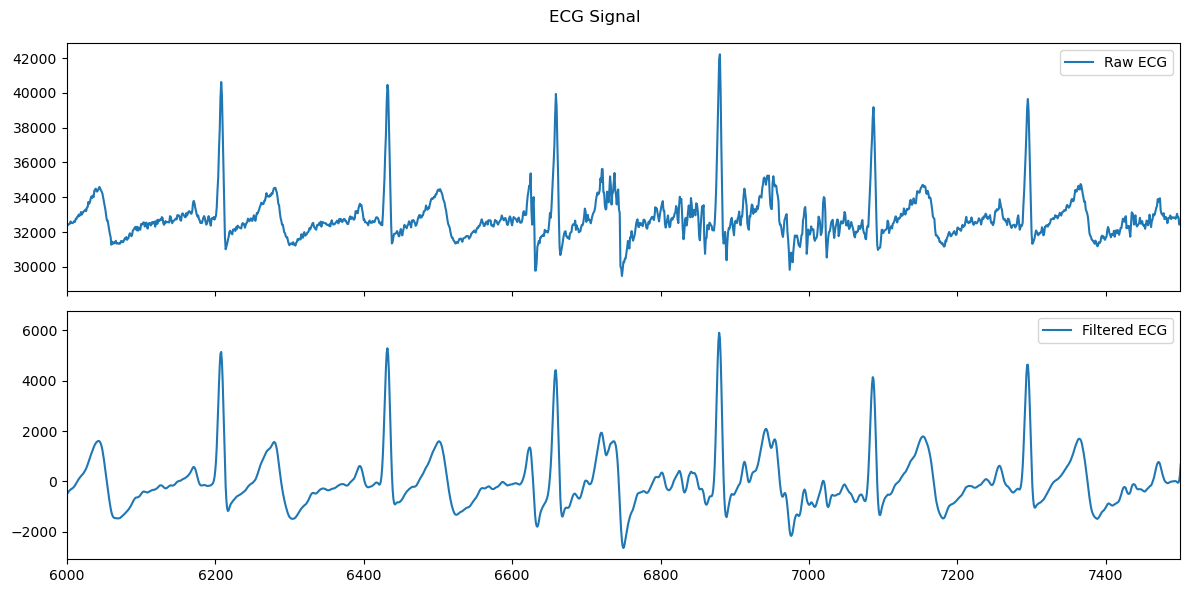

In [27]:
# compare a raw and cleaned signal 
file_path = r"C:\Users\Laerke\Documents\DTU\Teknisk Biomedicin\SS 26\BSc\EKG\EKG filer - 04.02.26\Laerke_VR2.txt"

column_names = ['nSeq' , 'DI' , 'CH1' , 'Extra']
data = pd.read_csv(file_path , sep = "\t" , comment = "#" , header = None , names = column_names)

data["CH1"] = pd.to_numeric(data["CH1"] , errors = "coerce")
ecg = data["CH1"].dropna()

sampling_rate = 300
ecg_clean = nk.ecg_clean(ecg , sampling_rate = sampling_rate)

def plot_signals(raw , clean , title):
    fig, axs = plt.subplots(2 , 1 , figsize = (12 , 6) , sharex = "all")
    plt.subplot(2 , 1 , 1)
    plt.plot(raw , label = f'Raw {title}')
    plt.xlim([6000 , 7500])
    plt.legend()
    plt.subplot(2 , 1 , 2)
    plt.plot(clean , label = f'Filtered {title}')
    plt.legend()
    plt.suptitle(f"{title} Signal")
    plt.tight_layout()
    plt.show()

plot_signals(ecg , ecg_clean , "ECG")

#### Graph of Power Spectral Density (PSD) for Frequency domain 

In this project we have decided against using calculations in the frequency domain, partly due to the length of recordings. 

The below figure illustrates how a signal can be divided into different frequency bands. 

As the used signal is fairly short (195s / 3.25min) we see a significant density of the HF band, while VLF and ULF are absent. 

To properly record these lower frequency, a longer recording is typically required. 

   HRV_ULF   HRV_VLF   HRV_LF    HRV_HF   HRV_VHF    HRV_TP  HRV_LFHF  \
0      NaN  0.001109  0.00217  0.000695  0.000019  0.003992  3.123443   

    HRV_LFn   HRV_HFn  HRV_LnHF  
0  0.543527  0.174015 -7.272004  


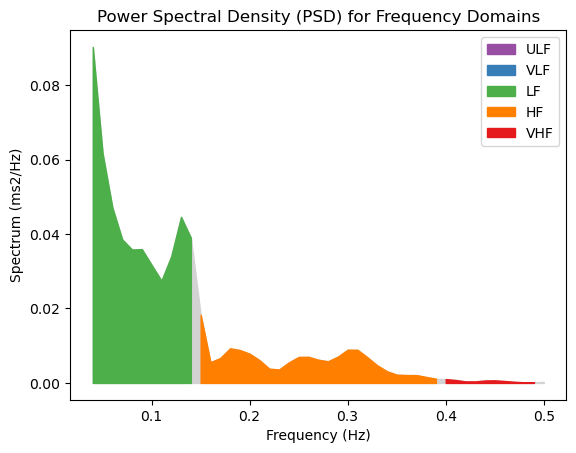

In [28]:
peaks, info = nk.ecg_peaks(ecg_clean , sampling_rate = sampling_rate, correct_artifacts = True)
hrv_freq = nk.hrv_frequency(peaks , sampling_rate = sampling_rate , show = True , normalize = True)
hrv_freq 
print(hrv_freq) 
plt.show() 